In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Results from all images



In [20]:
stats = pd.read_csv("data_output_stats_report.txt", sep=' ', header= None)

#mean dist of image 31
xmc_mean = pd.read_csv("im32_data_array_x.txt", sep=' ', header= None)

stats.columns= ["name", "x_mean", "x_mean_std", "x_std_mean", "y_mean", "y_mean_std", "y_std_mean", "x_mean_in_mm", "x_std_in_mm", "y_mean_in_mm", "y_std_in_mm"]

In [52]:
x_pics =  np.arange(6-6,56-6)
scale = 5/41 #1 pixel in mm

#need to convert std of the mean to mm
stats["x_mean_std_mm"] = stats["x_mean_std"]*scale

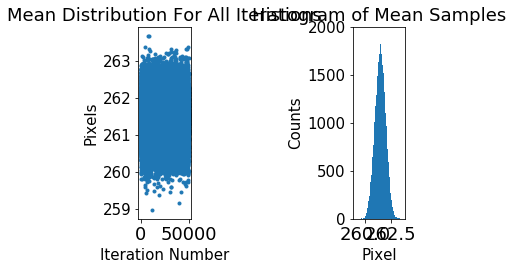

In [53]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_mean[0], marker='.', linewidth=0)
ax1.hist(xmc_mean[0], bins=100)
#ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of Mean Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("Mean Distribution For All Iterations")

plt.tight_layout()
plt.savefig("im32_x_mean_hist", dpi = 300)

In [54]:
#dispersion
disp = 1363 #mm/dB/B


## meand and std (no error saved on std), both in pixels

Text(0, 0.5, 'Pixels')

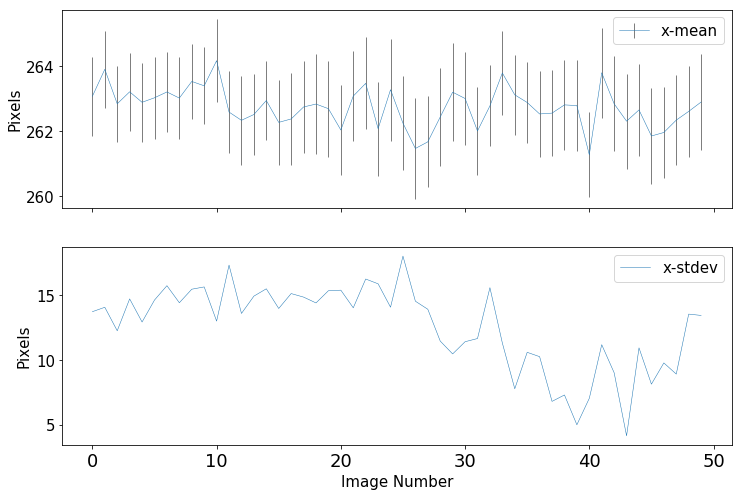

In [55]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True,figsize=(12,8))
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['x_mean'], yerr =2*stats["x_mean_std"] + 0.5, linewidth=0.5, ecolor='black', capthick=2, label="x-mean")
ax.legend()

ax1.errorbar(x_pics, stats['x_std_mean'], linewidth=0.5, ecolor='black', capthick=2, label='x-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

#plt.savefig("x_mean_stdev_allim", dpi = 300)

In [56]:
import matplotlib as mlt

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 15}

mlt.rc('font', **font)

## mean in mm (top) and mean in dispersion (bottom) with mean_std

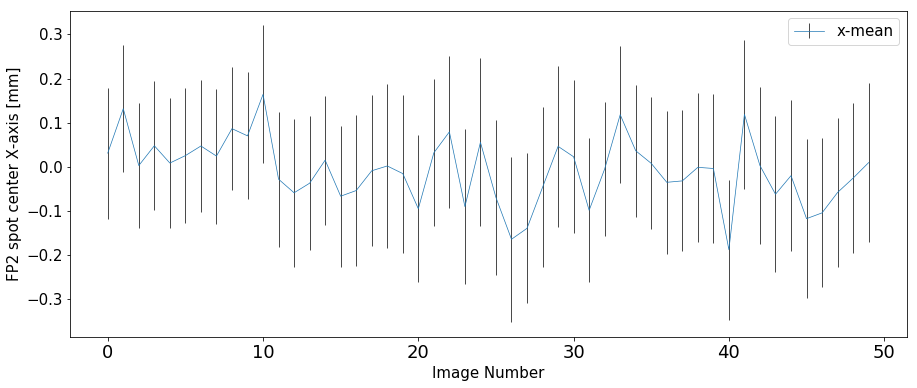

In [85]:
fig = plt.figure(figsize=(15,6))

plt.errorbar(x_pics, stats['x_mean_in_mm']-32.05, yerr =(2*stats["x_mean_std_mm"]+0.5*scale), linewidth=0.7, ecolor='black', capthick=1, label="x-mean")
plt.legend()

plt.xlabel("Image Number")
plt.ylabel("FP2 spot center X-axis [mm]")

#make labels easier to read
#reset image number


plt.savefig("FP2_stability_x_axis", dpi = 300)